# VSL Low-Shot — TRAIN FROM SAVED KEYPOINTS

Notebook này **không chạy MediaPipe lại**.

Nó bắt đầu trực tiếp từ file đã tạo ở lần chạy trước:

- `vsl_keypoints_safe.npz` — ưu tiên
- fallback: `vsl_keypoints.npz`

Pipeline:

`vsl_keypoints_safe.npz → leakage-safe seen/unseen split → augmentation → P×K sampler → region-aware Transformer → SSL warm-up → SupCon + batch-hard Triplet → prototypes → UNKNOWN calibration → DTW`

## Cách dùng trên Kaggle

### Nếu file đang nằm trong Output của notebook cũ
1. Notebook cũ → **Save Version** để persist output.
2. Tạo notebook mới / upload notebook này.
3. **Add Input → Your Work / Notebook Output** → chọn output chứa `vsl_lowshot_final/vsl_keypoints_safe.npz`.
4. Bật GPU P100/T4.
5. **Run All**.

Notebook sẽ tự tìm file `.npz` trong `/kaggle/input` hoặc `/kaggle/working`.

> Không cần MediaPipe, không cần Internet, không extract lại 4.362 video.

In [1]:
# ============================================================
# 0. Environment — Kaggle P100/T4 compatible
# ============================================================
import os, sys, json, math, random, warnings, subprocess, importlib
from pathlib import Path
from collections import defaultdict

# ------------------------------------------------------------
# Kaggle Latest image may ship PyTorch + CUDA 12.8.
# Tesla P100 = Pascal (sm_60). Current cu128 PyTorch builds may
# not contain a runnable Pascal kernel image.
#
# For P100 only, install the official PyTorch CUDA 12.6 build
# BEFORE importing torch. T4 and newer GPUs keep Kaggle's stock
# PyTorch unless a CUDA smoke test later proves otherwise.
# ------------------------------------------------------------
def get_gpu_name():
    try:
        out = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
            text=True
        ).strip().splitlines()
        return out[0].strip() if out else ""
    except Exception:
        return ""

GPU_NAME_PREIMPORT = get_gpu_name()
print("GPU detected before torch import:", GPU_NAME_PREIMPORT or "unknown")

IS_P100 = "P100" in GPU_NAME_PREIMPORT.upper()

if IS_P100:
    # Inspect installed torch version without importing torch.
    try:
        from importlib.metadata import version as pkg_version
        installed_torch = pkg_version("torch")
    except Exception:
        installed_torch = None

    print("Installed torch package:", installed_torch)

    # Force the official cu126 wheel. It has a CPython 3.12 Linux wheel.
    # We use --force-reinstall because torch==2.10.0+cu128 and +cu126
    # have the same public version but different CUDA local tags.
    if installed_torch != "2.10.0+cu126":
        print("P100 detected -> installing PyTorch 2.10.0+cu126 ...")
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q",
            "--force-reinstall",
            "torch==2.10.0+cu126",
            "--index-url", "https://download.pytorch.org/whl/cu126"
        ])
        print("PyTorch cu126 installation finished.")

# Scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Import torch ONLY after optional P100 compatibility install.
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler

warnings.filterwarnings("ignore")

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("PyTorch:", torch.__version__)
print("torch.version.cuda:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU capability:", torch.cuda.get_device_capability(0))
    print("Torch compiled CUDA archs:", torch.cuda.get_arch_list())

    # Fail early before loading 180 MB of keypoints or building the model.
    capability = torch.cuda.get_device_capability(0)
    required_arch = f"sm_{capability[0]}{capability[1]}"
    archs = set(torch.cuda.get_arch_list())

    if required_arch not in archs:
        raise RuntimeError(
            f"This PyTorch build does not contain {required_arch} for "
            f"{torch.cuda.get_device_name(0)}. Compiled archs={sorted(archs)}. "
            "On Kaggle P100 use this notebook from a FRESH session; "
            "alternatively switch Accelerator to T4."
        )

    # Real kernel launch smoke test.
    try:
        _smoke = torch.tensor([1.0, 2.0], device="cuda")
        _smoke = (_smoke * 2.0 + 1.0).sum()
        torch.cuda.synchronize()
        print("CUDA kernel smoke test: PASS ->", float(_smoke.cpu()))
    except Exception as e:
        raise RuntimeError(
            "CUDA kernel smoke test failed before training. "
            "Restart the Kaggle session and Run All, or switch to a T4 GPU."
        ) from e

print("Environment compatibility: PASS")

GPU detected before torch import: Tesla P100-PCIE-16GB
Installed torch package: 2.10.0+cu128
P100 detected -> installing PyTorch 2.10.0+cu126 ...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 170.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 101.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 182.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 64.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 92.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 105.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 160.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 MB 112.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 MB 117.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.2/287.2 MB 111.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
cupy-cuda12x 14.0.1 requires cuda-pathfinder==1.*,>=1.3.3, but you have cuda-pathfinder 1.2.2 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.4.0 which is incompatible.


PyTorch cu126 installation finished.
Python: 3.12.13
NumPy: 2.0.2
Pandas: 2.3.3
PyTorch: 2.10.0+cu126
torch.version.cuda: 12.6
CUDA available: True
GPU: Tesla P100-PCIE-16GB
GPU capability: (6, 0)
Torch compiled CUDA archs: ['sm_50', 'sm_60', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90']
CUDA kernel smoke test: PASS -> 8.0
Environment compatibility: PASS


### P100 compatibility

Kaggle's **Latest** environment may provide a CUDA 12.8 PyTorch build.
Tesla P100 is a Pascal GPU (`sm_60`). This notebook detects P100 **before importing
PyTorch** and switches to the official `torch 2.10.0 + CUDA 12.6` wheel.

If the package is changed, use a **fresh Kaggle session** for the run. T4 does not
need this downgrade and keeps the stock environment.

In [2]:
# ============================================================
# 1. CENTRAL CONFIG
# ============================================================
SEED = 42

# Optional manual path. Leave None for auto-discovery.
MANUAL_KEYPOINT_FILE = None
# Example:
# MANUAL_KEYPOINT_FILE = "/kaggle/input/<old-notebook-output>/vsl_lowshot_final/vsl_keypoints_safe.npz"

# Evaluation split
UNSEEN_EVAL_MAX_CLASSES = 100
UNSEEN_EVAL_FRACTION = 0.15
SEEN_VAL_FRACTION = 0.20
UNSEEN_SUPPORT_PER_CLASS = 1

# Augmentation — intentionally mild
TEMP_SPEED_MIN = 0.85
TEMP_SPEED_MAX = 1.15
TEMP_CROP_MIN_KEEP = 0.85
ROT_DEG = 5.0
SCALE_MIN = 0.94
SCALE_MAX = 1.06
TRANSLATE_STD = 0.015
KEYPOINT_NOISE_STD = 0.006
FRAME_DROP_MAX = 0.07
POINT_DROP_PROB = 0.005

# Numerical safety
COORD_CLIP = 8.0
LOCAL_HAND_CLIP = 6.0
MIN_HAND_SCALE = 0.04
NUM_WORKERS = 0

# Model
REGION_DIM = 96
D_MODEL = 256
NHEAD = 8
NUM_TRANSFORMER_LAYERS = 3
FF_DIM = 512
DROPOUT = 0.12
EMBED_DIM = 256
USE_HAND_ANGLE_FEATURES = True

# SSL warm-up
SELF_SUP_EPOCHS = 3
SELF_SUP_BATCH = 96
SELF_SUP_TEMP = 0.10
SSL_FORCE_FP32 = True

# Metric-learning
PK_P = 24
PK_K = 2
BATCHES_PER_EPOCH = 220
METRIC_EPOCHS = 25
LR = 3e-4
WEIGHT_DECAY = 1e-4
SUPCON_TEMP = 0.07
TRIPLET_MARGIN = 0.20
TRIPLET_WEIGHT = 0.20
GRAD_ACCUM_STEPS = 1
MAX_GRAD_NORM = 1.0

# Production prototypes / retrieval
STABILIZED_PROTO_AUGS = 4
DTW_TOPK = 7
COSINE_WEIGHT = 0.78
DTW_WEIGHT = 0.22

DEFAULT_UNKNOWN_COS = 0.55
DEFAULT_UNKNOWN_MARGIN = 0.02

EXPORT_ONNX = False

WORK_DIR = Path("/kaggle/working/vsl_train_from_keypoints")
EXPORT_DIR = WORK_DIR / "export"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.benchmark = True

seed_everything(SEED)
print("DEVICE:", DEVICE)

DEVICE: cuda


## 2. Load saved keypoints

Notebook tự nhận cả hai format:

### Format A
`vsl_keypoints_safe.npz`

### Format B — đúng với Input trong ảnh của bạn
```text
vsl_keypoints_safe/
├── X.npy
├── y.npy
├── labels_str.npy
└── video_paths.npy
```

Không cần gộp lại thành `.npz`.

In [3]:
# ============================================================
# 2. Auto-discover saved keypoint dataset
# Supports BOTH:
#   A) vsl_keypoints_safe.npz / vsl_keypoints.npz
#   B) folder containing X.npy, y.npy, labels_str.npy, video_paths.npy
# ============================================================

def discover_saved_keypoints():
    # --------------------------------------------------------
    # Manual override
    # --------------------------------------------------------
    if MANUAL_KEYPOINT_FILE:
        p = Path(MANUAL_KEYPOINT_FILE)
        if not p.exists():
            raise FileNotFoundError(p)

        if p.is_file():
            return {"type": "npz", "path": p}

        if p.is_dir():
            required = ["X.npy", "y.npy"]
            if all((p / name).exists() for name in required):
                return {"type": "npy_dir", "path": p}

        raise RuntimeError(
            f"MANUAL_KEYPOINT_FILE không phải NPZ hợp lệ hoặc folder NPY hợp lệ: {p}"
        )

    roots = [Path("/kaggle/input"), Path("/kaggle/working")]

    # --------------------------------------------------------
    # 1) Prefer .npz if available
    # --------------------------------------------------------
    for name in ["vsl_keypoints_safe.npz", "vsl_keypoints.npz"]:
        hits = []
        for root in roots:
            if root.exists():
                hits.extend(root.rglob(name))

        if hits:
            hits = sorted(
                set(hits),
                key=lambda p: (
                    0 if str(p).startswith("/kaggle/input") else 1,
                    len(p.parts),
                    str(p)
                )
            )
            return {"type": "npz", "path": hits[0]}

    # --------------------------------------------------------
    # 2) Detect folder containing X.npy + y.npy
    #    This matches the Kaggle dataset shown in your screenshot.
    # --------------------------------------------------------
    candidate_dirs = []

    for root in roots:
        if not root.exists():
            continue

        for x_path in root.rglob("X.npy"):
            folder = x_path.parent
            if (folder / "y.npy").exists():
                candidate_dirs.append(folder)

    if candidate_dirs:
        candidate_dirs = sorted(
            set(candidate_dirs),
            key=lambda p: (
                0 if str(p).startswith("/kaggle/input") else 1,
                len(p.parts),
                str(p)
            )
        )
        return {"type": "npy_dir", "path": candidate_dirs[0]}

    raise FileNotFoundError(
        "Không tìm thấy dữ liệu keypoint.\n"
        "Notebook hỗ trợ:\n"
        "  - vsl_keypoints_safe.npz / vsl_keypoints.npz\n"
        "  - hoặc folder chứa X.npy + y.npy (+ labels_str.npy + video_paths.npy)\n"
        "Hãy kiểm tra Add Input trên Kaggle."
    )


SOURCE = discover_saved_keypoints()
print("Detected source:", SOURCE)

# ============================================================
# Load source
# ============================================================
if SOURCE["type"] == "npz":
    KEYPOINT_FILE = SOURCE["path"]

    print("Loading NPZ:", KEYPOINT_FILE)
    print("Size MB:", round(KEYPOINT_FILE.stat().st_size / 1024**2, 2))

    d = np.load(KEYPOINT_FILE, allow_pickle=True)

    if "X" not in d.files or "y" not in d.files:
        raise RuntimeError(f"NPZ thiếu X/y. Keys hiện có: {d.files}")

    X = d["X"].astype(np.float32)
    y = d["y"].astype(np.int64)

    labels_str = (
        d["labels_str"].astype(object)
        if "labels_str" in d.files
        else np.asarray([str(v) for v in y], dtype=object)
    )

    video_paths = (
        d["video_paths"].astype(object)
        if "video_paths" in d.files
        else np.asarray([f"sample_{i}" for i in range(len(X))], dtype=object)
    )

else:
    NPY_DIR = SOURCE["path"]

    print("Loading NPY directory:", NPY_DIR)

    x_path = NPY_DIR / "X.npy"
    y_path = NPY_DIR / "y.npy"
    label_path = NPY_DIR / "labels_str.npy"
    paths_path = NPY_DIR / "video_paths.npy"

    print("X.npy:", round(x_path.stat().st_size / 1024**2, 2), "MB")
    print("y.npy:", round(y_path.stat().st_size / 1024**2, 2), "MB")

    # mmap_mode="r" keeps initial RAM use low.
    # Convert to float32 afterward because training/augmentation expects writable arrays.
    X = np.load(x_path, mmap_mode="r", allow_pickle=False)
    y = np.load(y_path, allow_pickle=False).astype(np.int64)

    if label_path.exists():
        labels_str = np.load(label_path, allow_pickle=True).astype(object)
    else:
        labels_str = np.asarray([str(v) for v in y], dtype=object)

    if paths_path.exists():
        video_paths = np.load(paths_path, allow_pickle=True).astype(object)
    else:
        video_paths = np.asarray([f"sample_{i}" for i in range(len(X))], dtype=object)

    # Copy once into normal float32 RAM array.
    X = np.asarray(X, dtype=np.float32)

assert len(X) == len(y) == len(labels_str) == len(video_paths), (
    len(X), len(y), len(labels_str), len(video_paths)
)

print("X shape:", X.shape, "| dtype:", X.dtype)
print("y shape:", y.shape)
print("labels:", len(np.unique(y)))
print("Load: OK")

Detected source: {'type': 'npy_dir', 'path': PosixPath('/kaggle/input/datasets/dsfsdfdssdfdsf/vsl-keypoints-safe')}
Loading NPY directory: /kaggle/input/datasets/dsfsdfdssdfdsf/vsl-keypoints-safe
X.npy: 183.7 MB
y.npy: 0.03 MB
X shape: (4362, 48, 115, 4) | dtype: float32
y shape: (4362,)
labels: 3315
Load: OK


In [4]:
# ============================================================
# 3. Numerical audit + representation constants
# ============================================================
if X.ndim != 4 or X.shape[-1] != 4:
    raise ValueError(f"Expected X [N,T,P,4], got {X.shape}")

SEQ_LEN = int(X.shape[1])
N_POINTS = int(X.shape[2])
POINT_DIM = 4

N_POSE = 33
N_HAND = 21
N_FACE = max(0, N_POINTS - N_POSE - 2*N_HAND)
USE_FACE = N_FACE > 0
# Original MediaPipe face indices are no longer needed at training time;
# X.npy already contains the selected compact 40-point face representation.
FACE_SOURCE_INDICES = []

if N_POINTS < N_POSE + 2*N_HAND:
    raise ValueError(f"N_POINTS={N_POINTS} is too small for pose + two hands")

POSE_SLICE = slice(0, N_POSE)
LH_SLICE = slice(N_POSE, N_POSE + N_HAND)
RH_SLICE = slice(N_POSE + N_HAND, N_POSE + 2*N_HAND)
FACE_SLICE = slice(N_POSE + 2*N_HAND, N_POINTS)

BODY_IDS = torch.tensor([0, 11, 12, 13, 14, 15, 16, 23, 24], dtype=torch.long)

bad_before = int((~np.isfinite(X).reshape(len(X), -1).all(axis=1)).sum())
print("Non-finite samples before sanitize:", bad_before)

X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
X[..., 3] = np.clip(X[..., 3], 0.0, 1.0)
X[..., :3] = np.clip(X[..., :3], -COORD_CLIP, COORD_CLIP)
X[..., :3] *= (X[..., 3:4] > 1e-6).astype(np.float32)

assert np.isfinite(X).all()

unique_y = np.unique(y)
label_to_name = {}
for lab in unique_y:
    vals = labels_str[y == lab]
    label_to_name[int(lab)] = str(vals[0]) if len(vals) else str(int(lab))
id_to_label = label_to_name

counts = pd.Series(y).value_counts()

print({
    "samples": len(X),
    "classes": len(unique_y),
    "seq_len": SEQ_LEN,
    "points": N_POINTS,
    "face_points": N_FACE,
    "use_face": USE_FACE,
    "one_shot_classes": int((counts == 1).sum()),
    "multi_shot_classes": int((counts >= 2).sum()),
    "max_abs_coord": float(np.max(np.abs(X[..., :3]))),
})

Non-finite samples before sanitize: 0
{'samples': 4362, 'classes': 3315, 'seq_len': 48, 'points': 115, 'face_points': 40, 'use_face': True, 'one_shot_classes': 2765, 'multi_shot_classes': 550, 'max_abs_coord': 8.0}


,videos_per_gloss,num_glosses
0,1,2765
1,2,61
2,3,483
3,4,5
4,6,1


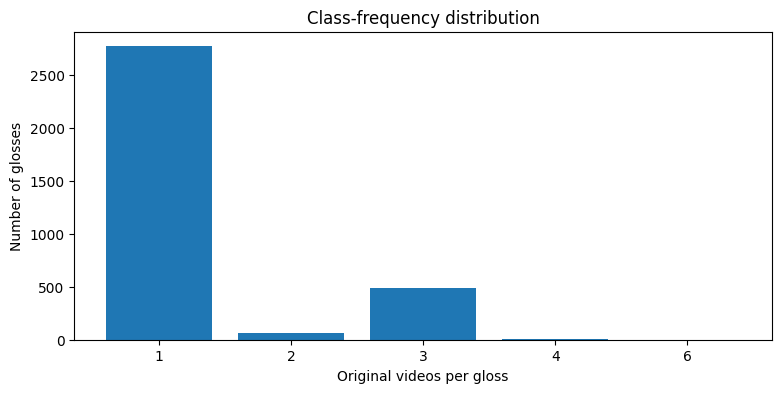

In [5]:
# ============================================================
# 4. Dataset audit plot
# ============================================================
freq = counts.value_counts().sort_index()

display(
    pd.DataFrame({
        "videos_per_gloss": freq.index.astype(int),
        "num_glosses": freq.values.astype(int),
    })
)

plt.figure(figsize=(9, 4))
plt.bar(freq.index.astype(str), freq.values)
plt.xlabel("Original videos per gloss")
plt.ylabel("Number of glosses")
plt.title("Class-frequency distribution")
plt.show()

## 5. Leakage-safe split

- Multi-shot glosses: một phần được giữ hoàn toàn khỏi training để test **unseen 1-shot**.
- Seen multi-shot glosses: tách original video cho validation.
- One-shot glosses: train-only; không giả vờ rằng augmentation là independent test.

In [6]:
# ============================================================
# 10. Seen / unseen split
# ============================================================
rng = np.random.default_rng(SEED)
label_to_indices = {int(l): np.where(y == l)[0] for l in np.unique(y)}
multi_labels = np.array([l for l, idx in label_to_indices.items() if len(idx) >= 2], dtype=np.int64)

n_unseen = min(
    UNSEEN_EVAL_MAX_CLASSES,
    max(1, int(round(len(multi_labels) * UNSEEN_EVAL_FRACTION))) if len(multi_labels) else 0,
)
unseen_labels = set(rng.choice(multi_labels, size=n_unseen, replace=False).tolist()) if n_unseen else set()

train_idx, seen_val_idx = [], []
unseen_support_idx, unseen_query_idx = [], []
one_shot_train_labels = []

for lab, idxs0 in label_to_indices.items():
    idxs = rng.permutation(idxs0)

    if lab in unseen_labels:
        unseen_support_idx.extend(idxs[:UNSEEN_SUPPORT_PER_CLASS].tolist())
        unseen_query_idx.extend(idxs[UNSEEN_SUPPORT_PER_CLASS:].tolist())
        continue

    if len(idxs) == 1:
        train_idx.extend(idxs.tolist())
        one_shot_train_labels.append(lab)
        continue

    n_val = max(1, int(round(len(idxs) * SEEN_VAL_FRACTION)))
    n_val = min(n_val, len(idxs)-1)
    seen_val_idx.extend(idxs[:n_val].tolist())
    train_idx.extend(idxs[n_val:].tolist())

train_idx = np.asarray(train_idx, np.int64)
seen_val_idx = np.asarray(seen_val_idx, np.int64)
unseen_support_idx = np.asarray(unseen_support_idx, np.int64)
unseen_query_idx = np.asarray(unseen_query_idx, np.int64)

sets = [set(a.tolist()) for a in [train_idx, seen_val_idx, unseen_support_idx, unseen_query_idx]]
for i in range(len(sets)):
    for j in range(i+1, len(sets)):
        assert sets[i].isdisjoint(sets[j]), (i, j, "split leakage")

print("Train original videos:", len(train_idx))
print("Seen validation videos:", len(seen_val_idx))
print("Unseen support videos:", len(unseen_support_idx))
print("Unseen query videos:", len(unseen_query_idx))
print("Held-out unseen glosses:", len(unseen_labels))
print("One-shot train-only glosses:", len(one_shot_train_labels))

Train original videos: 3655
Seen validation videos: 468
Unseen support videos: 82
Unseen query videos: 157
Held-out unseen glosses: 82
One-shot train-only glosses: 2765


In [7]:
# ============================================================
# 6. Sequence helpers used by augmentation
# ============================================================
def sanitize_sequence(x, coord_clip=COORD_CLIP):
    x = np.asarray(x, dtype=np.float32).copy()
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    x[..., 3] = np.clip(x[..., 3], 0.0, 1.0)
    x[..., :3] = np.clip(x[..., :3], -coord_clip, coord_clip)
    x[..., :3] *= (x[..., 3:4] > 1e-6).astype(np.float32)
    return x

def resample_sequence(seq, target_len):
    seq = sanitize_sequence(seq)
    if len(seq) == target_len:
        return seq
    if len(seq) == 1:
        return np.repeat(seq, target_len, axis=0).astype(np.float32)

    old_t = np.linspace(0.0, 1.0, len(seq))
    new_t = np.linspace(0.0, 1.0, target_len)
    flat = seq.reshape(len(seq), -1)
    out = np.empty((target_len, flat.shape[1]), dtype=np.float32)
    for j in range(flat.shape[1]):
        out[:, j] = np.interp(new_t, old_t, flat[:, j])
    return sanitize_sequence(out.reshape(target_len, seq.shape[1], seq.shape[2]))

## 7. On-the-fly skeleton / temporal augmentation

In [8]:
# ============================================================
# 11. Structured skeleton augmentation
# ============================================================
def temporal_resample_at_positions(seq, positions):
    T = len(seq)
    flat = seq.reshape(T, -1)
    base = np.arange(T)
    out = np.empty((len(positions), flat.shape[1]), dtype=np.float32)
    for j in range(flat.shape[1]):
        out[:, j] = np.interp(positions, base, flat[:, j])
    return out.reshape(len(positions), seq.shape[1], seq.shape[2])


def temporal_warp(seq, rng):
    T = len(seq)
    speed = rng.uniform(TEMP_SPEED_MIN, TEMP_SPEED_MAX)
    center = (T-1)/2
    pos = (np.arange(T)-center)*speed + center
    return temporal_resample_at_positions(seq, np.clip(pos, 0, T-1))


def temporal_crop(seq, rng):
    T = len(seq)
    keep = rng.uniform(TEMP_CROP_MIN_KEEP, 1.0)
    span = max(2, int(round(T*keep)))
    start = int(rng.integers(0, max(1, T-span+1)))
    cropped = seq[start:start+span]
    return resample_sequence(cropped, T)


def frame_dropout(seq, rng):
    x = seq.copy()
    p = rng.uniform(0.0, FRAME_DROP_MAX)
    drop = rng.random(len(x)) < p
    drop[0] = False; drop[-1] = False
    for i in np.where(drop)[0]:
        x[i] = 0.5*(x[i-1] + x[i+1])
    return x


def spatial_augment(seq, rng):
    x = seq.copy()
    xyz = x[..., :3]
    mask = x[..., 3:4]

    theta = np.deg2rad(rng.uniform(-ROT_DEG, ROT_DEG))
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c,-s],[s,c]], np.float32)
    xyz[..., :2] = xyz[..., :2] @ R.T

    xyz *= rng.uniform(SCALE_MIN, SCALE_MAX)
    xyz[..., :2] += rng.normal(0.0, TRANSLATE_STD, size=(1,1,2)).astype(np.float32)
    xyz += rng.normal(0.0, KEYPOINT_NOISE_STD, size=xyz.shape).astype(np.float32) * mask

    # Smooth hand-only drift approximates signer articulation variability without random label-destroying jumps.
    t = np.linspace(0, 2*np.pi, len(x), dtype=np.float32)
    amp = rng.uniform(0.0, 0.010)
    drift = (amp*np.sin(t + rng.uniform(0, 2*np.pi)))[:,None,None]
    xyz[:, LH_SLICE, 0:1] += drift
    xyz[:, RH_SLICE, 1:2] -= 0.5*drift

    # sparse point detector dropout
    pd = rng.random(mask.shape[:-1]) < POINT_DROP_PROB
    x[pd] = 0.0

    xyz *= x[..., 3:4]
    x[..., :3] = xyz
    return sanitize_sequence(x, COORD_CLIP)


def augment_sequence(seq, rng, mild=False):
    x = seq.astype(np.float32).copy()
    if rng.random() < (0.60 if mild else 0.85):
        x = temporal_warp(x, rng)
    if not mild and rng.random() < 0.45:
        x = temporal_crop(x, rng)
    if rng.random() < (0.30 if mild else 0.55):
        x = frame_dropout(x, rng)
    if rng.random() < 0.90:
        x = spatial_augment(x, rng)
    return x.astype(np.float32)

## 8. P×K sampler for extreme low-shot metric learning

In [9]:
# ============================================================
# 12. Dataset + low-shot-aware P×K batch sampler
# ============================================================
class AugmentedSubset(Dataset):
    def __init__(self, X, y, indices, augment=True, seed=42):
        self.X = X
        self.y = y
        self.indices = np.asarray(indices, dtype=np.int64)
        self.augment = augment
        self.seed = seed

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, local_i):
        global_i = int(self.indices[local_i])
        x = self.X[global_i].astype(np.float32)
        if self.augment:
            # random worker RNG + stable sample contribution
            s = (self.seed + global_i*1000003 + np.random.randint(0, 2**31-1)) % (2**32-1)
            x = augment_sequence(x, np.random.default_rng(s))
        x = sanitize_sequence(x, COORD_CLIP)
        return torch.from_numpy(x), torch.tensor(int(self.y[global_i]), dtype=torch.long), torch.tensor(global_i)


class PKBatchSampler(Sampler):
    def __init__(self, labels, P=24, K=2, batches_per_epoch=200, seed=42):
        self.labels = np.asarray(labels)
        self.P = P
        self.K = K
        self.batches_per_epoch = batches_per_epoch
        self.seed = seed
        self.epoch = 0
        self.by_label = {int(l): np.where(self.labels == l)[0] for l in np.unique(self.labels)}
        self.unique_labels = np.array(sorted(self.by_label.keys()), dtype=np.int64)

    def set_epoch(self, epoch):
        self.epoch = epoch

    def __len__(self):
        return self.batches_per_epoch

    def __iter__(self):
        rng = np.random.default_rng(self.seed + self.epoch)
        for _ in range(self.batches_per_epoch):
            replace_labels = len(self.unique_labels) < self.P
            chosen_labels = rng.choice(self.unique_labels, size=self.P, replace=replace_labels)
            batch = []
            for lab in chosen_labels:
                pool = self.by_label[int(lab)]
                replace = len(pool) < self.K
                batch.extend(rng.choice(pool, size=self.K, replace=replace).tolist())
            rng.shuffle(batch)
            yield batch


train_ds = AugmentedSubset(X, y, train_idx, augment=True, seed=SEED)
pk_sampler = PKBatchSampler(y[train_idx], P=PK_P, K=PK_K, batches_per_epoch=BATCHES_PER_EPOCH, seed=SEED)
train_loader = DataLoader(
    train_ds,
    batch_sampler=pk_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

xb, yb, ib = next(iter(train_loader))
print("batch:", xb.shape, yb.shape, "unique labels:", yb.unique().numel())

batch: torch.Size([48, 48, 115, 4]) torch.Size([48]) unique labels: 24


## 9. Region-aware features and encoder

In [10]:
# ============================================================
# 13. Region feature functions (PyTorch, GPU friendly)
# ============================================================
def first_order_motion(coords, mask):
    d = torch.zeros_like(coords)
    valid_pair = mask[:,1:] * mask[:,:-1]
    d[:,1:] = (coords[:,1:] - coords[:,:-1]) * valid_pair
    return d


def hand_local_features(hand):
    # hand [B,T,21,4]
    xyz = torch.nan_to_num(hand[..., :3], nan=0.0, posinf=0.0, neginf=0.0)
    mask = hand[..., 3:4].clamp(0.0, 1.0)

    wrist = xyz[..., 0:1, :]
    wrist_ok = mask[..., 0:1, :] > 0.5
    mcp9_ok = mask[..., 9:10, :] > 0.5
    anchor_ok = wrist_ok & mcp9_ok

    raw_scale = torch.linalg.norm(
        xyz[..., 9:10, :] - wrist,
        dim=-1,
        keepdim=True
    )

    # If either anchor is missing, do not create huge local coordinates.
    scale = torch.where(
        anchor_ok,
        raw_scale.clamp_min(MIN_HAND_SCALE),
        torch.ones_like(raw_scale)
    )

    local = (xyz - wrist) / scale

    # Require a valid wrist to define wrist-relative coordinates.
    local = local * mask * wrist_ok.to(local.dtype)
    local = torch.nan_to_num(local, nan=0.0, posinf=0.0, neginf=0.0)
    local = local.clamp(-LOCAL_HAND_CLIP, LOCAL_HAND_CLIP)
    return local

def safe_angle(a, b, eps=1e-6):
    a = torch.nan_to_num(a, nan=0.0, posinf=0.0, neginf=0.0)
    b = torch.nan_to_num(b, nan=0.0, posinf=0.0, neginf=0.0)

    an = torch.linalg.norm(a, dim=-1).clamp_min(eps)
    bn = torch.linalg.norm(b, dim=-1).clamp_min(eps)

    cos = (a * b).sum(dim=-1) / (an * bn)
    cos = torch.nan_to_num(cos, nan=0.0, posinf=0.9999, neginf=-0.9999)
    return torch.acos(cos.clamp(-0.9999, 0.9999))

def hand_angle_descriptor(hand):
    # 20 geometry features per frame; invalid landmark combinations -> 0.
    xyz = torch.nan_to_num(hand[..., :3], nan=0.0, posinf=0.0, neginf=0.0)
    mask = hand[..., 3] > 0.5

    fingers = [
        [0,1,2,3,4], [0,5,6,7,8], [0,9,10,11,12],
        [0,13,14,15,16], [0,17,18,19,20]
    ]

    feats = []
    for f in fingers:
        for j in range(1, 4):
            a0, a1, a2 = f[j-1], f[j], f[j+1]
            v1 = xyz[..., a0, :] - xyz[..., a1, :]
            v2 = xyz[..., a2, :] - xyz[..., a1, :]
            ang = safe_angle(v1, v2)
            valid = mask[..., a0] & mask[..., a1] & mask[..., a2]
            feats.append(torch.where(valid, ang, torch.zeros_like(ang)))

    mcps = [1,5,9,13,17]
    rays = [xyz[..., i, :] - xyz[..., 0, :] for i in mcps]

    for i in range(4):
        ang = safe_angle(rays[i], rays[i+1])
        valid = mask[..., 0] & mask[..., mcps[i]] & mask[..., mcps[i+1]]
        feats.append(torch.where(valid, ang, torch.zeros_like(ang)))

    ang = safe_angle(rays[1], rays[4])
    valid = mask[..., 0] & mask[..., mcps[1]] & mask[..., mcps[4]]
    feats.append(torch.where(valid, ang, torch.zeros_like(ang)))

    return torch.stack(feats, dim=-1)

def flatten_region_basic(region):
    # coords + mask + first-order motion
    xyz = region[..., :3]
    mask = region[..., 3:4]
    motion = first_order_motion(xyz, mask)
    return torch.cat([
        (xyz*mask).flatten(-2),
        mask.flatten(-2),
        motion.flatten(-2),
    ], dim=-1)

In [11]:
# ============================================================
# 14. Region-aware temporal metric encoder
# ============================================================
class RegionMLP(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.LayerNorm(out_dim),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(out_dim, out_dim),
            nn.LayerNorm(out_dim),
        )
    def forward(self, x):
        return self.net(x)


class VSLMetricEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        body_n = len(BODY_IDS)
        body_in = body_n * (3 + 1 + 3)
        hand_in = N_HAND*(3+1) + N_HAND*3 + N_HAND*3  # global xyz+mask, local xyz, motion
        if USE_HAND_ANGLE_FEATURES:
            hand_in += 20
        face_in = (N_FACE*(3+1+3)) if USE_FACE else 0

        self.body_encoder = RegionMLP(body_in, REGION_DIM)
        self.hand_encoder = RegionMLP(hand_in, REGION_DIM)   # shared weights reduce overfit
        self.face_encoder = RegionMLP(face_in, REGION_DIM) if USE_FACE else None
        self.side_embed = nn.Parameter(torch.zeros(2, REGION_DIM))
        nn.init.normal_(self.side_embed, std=0.02)

        n_regions = 4 if USE_FACE else 3
        self.n_regions = n_regions
        self.gate = nn.Sequential(
            nn.Linear(n_regions*REGION_DIM, REGION_DIM), nn.GELU(),
            nn.Linear(REGION_DIM, n_regions),
        )
        self.fuse = nn.Sequential(
            nn.Linear(n_regions*REGION_DIM, D_MODEL),
            nn.LayerNorm(D_MODEL),
            nn.GELU(),
        )

        # local temporal inductive bias
        self.local_conv = nn.Sequential(
            nn.Conv1d(D_MODEL, D_MODEL, kernel_size=3, padding=1, groups=D_MODEL),
            nn.GELU(),
            nn.Conv1d(D_MODEL, D_MODEL, kernel_size=1),
            nn.Dropout(DROPOUT),
        )

        self.pos = nn.Parameter(torch.zeros(1, SEQ_LEN, D_MODEL))
        nn.init.trunc_normal_(self.pos, std=0.02)

        layer = nn.TransformerEncoderLayer(
            d_model=D_MODEL, nhead=NHEAD, dim_feedforward=FF_DIM,
            dropout=DROPOUT, activation="gelu", batch_first=True, norm_first=True,
        )
        self.temporal = nn.TransformerEncoder(layer, num_layers=NUM_TRANSFORMER_LAYERS)
        self.head = nn.Sequential(
            nn.LayerNorm(D_MODEL),
            nn.Linear(D_MODEL, D_MODEL), nn.GELU(), nn.Dropout(DROPOUT),
            nn.Linear(D_MODEL, EMBED_DIM),
        )

    def encode_hand(self, hand, side):
        xyz = hand[..., :3]
        mask = hand[..., 3:4]
        local = hand_local_features(hand)
        motion = first_order_motion(xyz, mask)
        parts = [(xyz*mask).flatten(-2), mask.flatten(-2), local.flatten(-2), motion.flatten(-2)]
        if USE_HAND_ANGLE_FEATURES:
            parts.append(hand_angle_descriptor(hand))
        h = self.hand_encoder(torch.cat(parts, dim=-1))
        return h + self.side_embed[side][None,None,:]

    def forward(self, x, return_regions=False):
        # x [B,T,P,4]
        x = torch.nan_to_num(x.float(), nan=0.0, posinf=0.0, neginf=0.0)
        x_xyz = x[..., :3].clamp(-COORD_CLIP, COORD_CLIP)
        x = torch.cat([x_xyz, x[..., 3:4].clamp(0.0, 1.0)], dim=-1)
        body_ids = BODY_IDS.to(x.device)
        body = x.index_select(2, body_ids)
        lh = x[:,:,LH_SLICE,:]
        rh = x[:,:,RH_SLICE,:]

        rb = self.body_encoder(flatten_region_basic(body))
        rl = self.encode_hand(lh, 0)
        rr = self.encode_hand(rh, 1)
        regions = [rb, rl, rr]

        if USE_FACE:
            face = x[:,:,FACE_SLICE,:]
            rf = self.face_encoder(flatten_region_basic(face))
            regions.append(rf)

        cat = torch.cat(regions, dim=-1)
        gates = torch.softmax(self.gate(cat), dim=-1)
        weighted = [r * gates[...,i:i+1] for i, r in enumerate(regions)]
        h = self.fuse(torch.cat(weighted, dim=-1))

        conv = self.local_conv(h.transpose(1,2)).transpose(1,2)
        h = h + conv + self.pos[:,:h.size(1)]
        h = self.temporal(h)
        pooled = h.mean(dim=1)
        pooled = torch.nan_to_num(pooled, nan=0.0, posinf=0.0, neginf=0.0)
        raw_z = torch.nan_to_num(self.head(pooled), nan=0.0, posinf=0.0, neginf=0.0)
        z = F.normalize(raw_z.float(), dim=-1, eps=1e-6)

        if return_regions:
            return z, regions, gates
        return z


model = VSLMetricEncoder().to(DEVICE)
params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {params/1e6:.2f}M")
with torch.no_grad():
    zz, regs, gg = model(xb[:2].to(DEVICE), return_regions=True)
    print("embedding:", zz.shape, "gates:", gg.shape)

Parameters: 2.01M
embedding: torch.Size([2, 256]) gates: torch.Size([2, 48, 4])


## 10. Self-supervised warm-up

Chạy hoàn toàn trên keypoints đã lưu. `SELF_SUP_EPOCHS=0` nếu muốn bỏ ablation này.

In [12]:
# ============================================================
# 15. Two-view SSL dataset + NT-Xent
# ============================================================
class TwoViewDataset(Dataset):
    def __init__(self, X, indices, seed=42):
        self.X = X
        self.indices = np.asarray(indices)
        self.seed = seed
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        gi = int(self.indices[i])
        x = self.X[gi].astype(np.float32)
        s = (self.seed + gi*15485863 + np.random.randint(0, 2**31-1)) % (2**32-1)
        v1 = augment_sequence(x, np.random.default_rng(s))
        v2 = augment_sequence(x, np.random.default_rng((s+99991)%(2**32-1)))
        return torch.from_numpy(v1), torch.from_numpy(v2)


def nt_xent(z1, z2, temperature=0.1):
    # Similarity/loss are explicitly FP32 for numerical stability.
    z1 = F.normalize(torch.nan_to_num(z1.float(), nan=0.0, posinf=0.0, neginf=0.0), dim=1, eps=1e-6)
    z2 = F.normalize(torch.nan_to_num(z2.float(), nan=0.0, posinf=0.0, neginf=0.0), dim=1, eps=1e-6)

    B = z1.size(0)
    if B < 2:
        return (z1.sum() + z2.sum()) * 0.0

    z = torch.cat([z1, z2], dim=0)
    logits = (z @ z.T) / float(temperature)

    # Use dtype-safe negative mask value; no -1e9 in float16.
    eye = torch.eye(2 * B, device=z.device, dtype=torch.bool)
    logits = logits.masked_fill(eye, -1e4)

    targets = torch.arange(2 * B, device=z.device)
    targets = (targets + B) % (2 * B)

    loss = F.cross_entropy(logits.float(), targets)
    return loss

ssl_loader = DataLoader(
    TwoViewDataset(X, train_idx, SEED), batch_size=SELF_SUP_BATCH, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(), drop_last=True,
)

In [13]:
# ============================================================
# 15b. Pre-training numerical smoke test
# ============================================================
model.eval()
with torch.no_grad():
    sv1, sv2 = next(iter(ssl_loader))
    sv1 = sv1[:8].to(DEVICE).float()
    sv2 = sv2[:8].to(DEVICE).float()

    print("Input finite:", bool(torch.isfinite(sv1).all() and torch.isfinite(sv2).all()))
    print("Input max abs:", float(torch.max(sv1.abs()).item()))

    sz1 = model(sv1)
    sz2 = model(sv2)

    print("Embedding finite:", bool(torch.isfinite(sz1).all() and torch.isfinite(sz2).all()))
    print("Embedding norm mean:", float(sz1.norm(dim=1).mean().item()))

    sloss = nt_xent(sz1, sz2, SELF_SUP_TEMP)
    print("Initial NT-Xent:", float(sloss.item()))

    assert torch.isfinite(sloss), "Initial SSL loss is NaN/Inf"
    assert torch.isfinite(sz1).all() and torch.isfinite(sz2).all(), "Embedding contains NaN/Inf"

model.train()
print("Pre-training numerical smoke test: PASS")

Input finite: True
Input max abs: 7.572221755981445
Embedding finite: True
Embedding norm mean: 1.0
Initial NT-Xent: 1.4249917268753052
Pre-training numerical smoke test: PASS


In [14]:
# ============================================================
# 16. SSL warm-up training — NaN-safe
# ============================================================
if SELF_SUP_EPOCHS > 0:
    ssl_opt = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    # SSL is only a short warm-up. FP32 is more important than a small speed gain.
    use_amp_ssl = torch.cuda.is_available() and (not SSL_FORCE_FP32)
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp_ssl)

    for ep in range(1, SELF_SUP_EPOCHS + 1):
        model.train()
        losses = []

        for step, (v1, v2) in enumerate(
            tqdm(ssl_loader, desc=f"SSL {ep}/{SELF_SUP_EPOCHS}", leave=False),
            start=1
        ):
            v1 = v1.to(DEVICE, non_blocking=True).float()
            v2 = v2.to(DEVICE, non_blocking=True).float()

            # Catch the real source rather than silently propagating NaNs.
            if not torch.isfinite(v1).all() or not torch.isfinite(v2).all():
                raise RuntimeError(
                    f"Non-finite SSL input at epoch={ep}, step={step}"
                )

            v1 = torch.nan_to_num(v1, nan=0.0, posinf=0.0, neginf=0.0)
            v2 = torch.nan_to_num(v2, nan=0.0, posinf=0.0, neginf=0.0)

            ssl_opt.zero_grad(set_to_none=True)

            if use_amp_ssl:
                with torch.autocast(device_type="cuda", dtype=torch.float16):
                    z1 = model(v1)
                    z2 = model(v2)
                # Loss outside autocast => FP32.
                loss = nt_xent(z1.float(), z2.float(), SELF_SUP_TEMP)
            else:
                z1 = model(v1)
                z2 = model(v2)
                loss = nt_xent(z1, z2, SELF_SUP_TEMP)

            if not torch.isfinite(z1).all() or not torch.isfinite(z2).all():
                raise RuntimeError(
                    f"Model produced NaN/Inf embedding at SSL epoch={ep}, step={step}"
                )

            if not torch.isfinite(loss):
                raise RuntimeError(
                    f"SSL loss became non-finite at epoch={ep}, step={step}; "
                    f"z1_max={z1.abs().max().item():.4f}, "
                    f"z2_max={z2.abs().max().item():.4f}"
                )

            scaler.scale(loss).backward()
            scaler.unscale_(ssl_opt)

            grad_norm = torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                MAX_GRAD_NORM
            )

            if not torch.isfinite(grad_norm):
                ssl_opt.zero_grad(set_to_none=True)
                raise RuntimeError(
                    f"Non-finite gradient at SSL epoch={ep}, step={step}"
                )

            scaler.step(ssl_opt)
            scaler.update()

            losses.append(float(loss.detach().cpu()))

        print(
            f"SSL epoch {ep}: {np.mean(losses):.4f} "
            f"(steps={len(losses)}, amp={use_amp_ssl})"
        )
else:
    print("SSL warm-up disabled")

SSL 1/3:   0%|          | 0/38 [00:00<?, ?it/s]

SSL epoch 1: 1.1195 (steps=38, amp=False)


SSL 2/3:   0%|          | 0/38 [00:00<?, ?it/s]

SSL epoch 2: 0.3478 (steps=38, amp=False)


SSL 3/3:   0%|          | 0/38 [00:00<?, ?it/s]

SSL epoch 3: 0.2466 (steps=38, amp=False)


## 11. SupCon + batch-hard Triplet

In [15]:
# ============================================================
# 17. Metric losses — FP32 numerically stable
# ============================================================
class SupConLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, z, labels):
        z = torch.nan_to_num(z.float(), nan=0.0, posinf=0.0, neginf=0.0)
        z = F.normalize(z, dim=1, eps=1e-6)

        logits = (z @ z.T) / float(self.temperature)
        logits = logits - logits.max(dim=1, keepdim=True).values.detach()

        eye = torch.eye(len(z), device=z.device, dtype=torch.bool)
        pos = labels[:, None].eq(labels[None, :]) & (~eye)

        # Stable masked log-softmax.
        masked_logits = logits.masked_fill(eye, -1e4)
        log_prob = F.log_softmax(masked_logits.float(), dim=1)

        npos = pos.sum(1)
        valid = npos > 0
        if not valid.any():
            return z.sum() * 0.0

        mean_pos = (pos * log_prob).sum(1) / npos.clamp_min(1)
        loss = -mean_pos[valid].mean()

        if not torch.isfinite(loss):
            raise RuntimeError("SupCon produced non-finite loss")
        return loss


def batch_hard_triplet(z, labels, margin=0.2):
    z = torch.nan_to_num(z.float(), nan=0.0, posinf=0.0, neginf=0.0)
    z = F.normalize(z, dim=1, eps=1e-6)

    dist = (1.0 - z @ z.T).clamp(0.0, 2.0)

    eye = torch.eye(len(z), device=z.device, dtype=torch.bool)
    same = labels[:, None].eq(labels[None, :])
    pos = same & (~eye)
    neg = ~same

    hp = dist.masked_fill(~pos, float("-inf")).max(1).values
    hn = dist.masked_fill(~neg, float("inf")).min(1).values

    valid = pos.any(1) & neg.any(1)
    if not valid.any():
        return z.sum() * 0.0

    loss = F.relu(hp[valid] - hn[valid] + margin).mean()
    if not torch.isfinite(loss):
        raise RuntimeError("Triplet produced non-finite loss")
    return loss


supcon_fn = SupConLoss(SUPCON_TEMP)

In [16]:
# ============================================================
# 18. Embedding / prototype / retrieval helpers
# ============================================================
@torch.no_grad()
def embed_indices(model, indices, batch_size=128):
    model.eval()
    out = []
    for s in range(0, len(indices), batch_size):
        ids = indices[s:s+batch_size]
        xb_ = torch.from_numpy(X[ids].astype(np.float32)).to(DEVICE)
        out.append(model(xb_).cpu().numpy())
    return np.concatenate(out) if out else np.empty((0, EMBED_DIM), np.float32)


def build_prototypes(emb, labels):
    labs = np.unique(labels)
    protos = []
    for lab in labs:
        p = emb[labels == lab].mean(0)
        p /= np.linalg.norm(p) + 1e-12
        protos.append(p)
    return np.asarray(protos, np.float32), labs.astype(np.int64)


def topk_predict(query_emb, prototypes, proto_labels, k=5):
    sim = query_emb @ prototypes.T
    k = min(k, prototypes.shape[0])
    order = np.argsort(-sim, axis=1)[:,:k]
    return proto_labels[order], np.take_along_axis(sim, order, axis=1)


def classification_metrics(query_emb, query_y, protos, proto_labels, k=5):
    if len(query_y) == 0 or len(proto_labels) == 0:
        return {"top1": np.nan, f"top{k}": np.nan}
    pred, scores = topk_predict(query_emb, protos, proto_labels, k)
    top1 = float(np.mean(pred[:,0] == query_y))
    topk = float(np.mean([query_y[i] in pred[i] for i in range(len(query_y))]))
    return {"top1": top1, f"top{k}": topk, "mean_top1_cos": float(scores[:,0].mean())}


def retrieval_metrics(query_emb, query_y, ref_emb, ref_y, ks=(1,5,10)):
    if len(query_y) == 0 or len(ref_y) == 0:
        return {f"recall@{k}": np.nan for k in ks} | {"mAP": np.nan, "MRR": np.nan}
    sim = query_emb @ ref_emb.T
    order = np.argsort(-sim, axis=1)
    recalls = {k: [] for k in ks}
    aps, rrs = [], []
    for i in range(len(query_y)):
        rel = (ref_y[order[i]] == query_y[i]).astype(np.float32)
        for k in ks:
            recalls[k].append(float(rel[:k].any()))
        hit_pos = np.where(rel > 0)[0]
        rrs.append(1.0/(hit_pos[0]+1) if len(hit_pos) else 0.0)
        if rel.sum() == 0:
            aps.append(0.0)
        else:
            c = np.cumsum(rel)
            precision = c / (np.arange(len(rel))+1)
            aps.append(float((precision*rel).sum()/rel.sum()))
    out = {f"recall@{k}": float(np.mean(v)) for k,v in recalls.items()}
    out.update({"mAP": float(np.mean(aps)), "MRR": float(np.mean(rrs))})
    return out

In [17]:
# ============================================================
# 19. Validation function — seen + true unseen 1-shot
# ============================================================
@torch.no_grad()
def evaluate_all(model):
    # Seen validation: prototypes only from seen TRAIN originals.
    tr_emb = embed_indices(model, train_idx)
    seen_protos, seen_proto_labels = build_prototypes(tr_emb, y[train_idx])

    sv_emb = embed_indices(model, seen_val_idx)
    seen_cls = classification_metrics(sv_emb, y[seen_val_idx], seen_protos, seen_proto_labels, 5)
    seen_ret = retrieval_metrics(sv_emb, y[seen_val_idx], tr_emb, y[train_idx])

    # Unseen 1-shot: encoder never trained on these glosses.
    us_emb = embed_indices(model, unseen_support_idx)
    uq_emb = embed_indices(model, unseen_query_idx)
    unseen_protos, unseen_proto_labels = build_prototypes(us_emb, y[unseen_support_idx])
    unseen_closed = classification_metrics(uq_emb, y[unseen_query_idx], unseen_protos, unseen_proto_labels, 5)
    unseen_ret = retrieval_metrics(uq_emb, y[unseen_query_idx], us_emb, y[unseen_support_idx])

    # Harder global dictionary: seen train prototypes + unseen one-shot prototypes.
    if len(unseen_proto_labels):
        global_p = np.concatenate([seen_protos, unseen_protos], axis=0)
        global_l = np.concatenate([seen_proto_labels, unseen_proto_labels], axis=0)
        unseen_global = classification_metrics(uq_emb, y[unseen_query_idx], global_p, global_l, 5)
    else:
        unseen_global = {"top1": np.nan, "top5": np.nan}

    return {
        "seen_top1": seen_cls.get("top1"), "seen_top5": seen_cls.get("top5"),
        "seen_mAP": seen_ret.get("mAP"),
        "unseen1shot_top1": unseen_closed.get("top1"), "unseen1shot_top5": unseen_closed.get("top5"),
        "unseen1shot_mAP": unseen_ret.get("mAP"),
        "unseen_global_top1": unseen_global.get("top1"), "unseen_global_top5": unseen_global.get("top5"),
    }

## 12. Metric-learning training

Checkpoint được chọn ưu tiên theo **unseen 1-shot Top-1**, sau đó fallback về seen Top-1.

In [18]:
# ============================================================
# 20. Train SupCon + batch-hard Triplet with AMP
# ============================================================
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, METRIC_EPOCHS))
scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

best_score = -1e9
best_path = EXPORT_DIR / "best_vsl_metric_encoder.pt"
history = []

for epoch in range(1, METRIC_EPOCHS+1):
    pk_sampler.set_epoch(epoch)
    model.train()
    optimizer.zero_grad(set_to_none=True)
    losses = []

    for step, (xbt, ybt, _) in enumerate(tqdm(train_loader, desc=f"Metric {epoch}/{METRIC_EPOCHS}", leave=False), 1):
        xbt = xbt.to(DEVICE, non_blocking=True)
        ybt = ybt.to(DEVICE, non_blocking=True)

        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=torch.cuda.is_available()):
            z = model(xbt)
            l_sc = supcon_fn(z, ybt)
            l_tri = batch_hard_triplet(z, ybt, TRIPLET_MARGIN)
            loss = (l_sc + TRIPLET_WEIGHT*l_tri) / GRAD_ACCUM_STEPS

        scaler.scale(loss).backward()

        if step % GRAD_ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            scaler.step(optimizer); scaler.update()
            optimizer.zero_grad(set_to_none=True)

        losses.append([float(loss.detach().cpu())*GRAD_ACCUM_STEPS, float(l_sc.detach().cpu()), float(l_tri.detach().cpu())])

    scheduler.step()
    m = np.mean(losses, axis=0)
    metrics = evaluate_all(model)
    row = {"epoch": epoch, "loss": m[0], "supcon": m[1], "triplet": m[2], **metrics}
    history.append(row)

    print(
        f"E{epoch:02d} loss={m[0]:.4f} | seen@1={metrics['seen_top1']:.4f} | "
        f"unseen1shot@1={metrics['unseen1shot_top1']:.4f} | global-unseen@1={metrics['unseen_global_top1']:.4f}"
    )

    score = metrics["unseen1shot_top1"]
    if score is None or np.isnan(score):
        score = metrics["seen_top1"]
    if score is None or np.isnan(score):
        score = -m[0]

    if score > best_score:
        best_score = float(score)
        torch.save({
            "model_state": model.state_dict(),
            "config": {
                "seq_len": SEQ_LEN, "n_points": N_POINTS, "use_face": USE_FACE,
                "face_idx": FACE_SOURCE_INDICES, "region_dim": REGION_DIM,
                "d_model": D_MODEL, "nhead": NHEAD, "layers": NUM_TRANSFORMER_LAYERS,
                "ff_dim": FF_DIM, "embed_dim": EMBED_DIM,
                "use_hand_angles": USE_HAND_ANGLE_FEATURES,
            },
            "epoch": epoch,
            "metrics": metrics,
        }, best_path)
        print(f"  ↳ Saved new best checkpoint: {best_path.name} (score={best_score:.4f})")

history_df = pd.DataFrame(history)
history_df.to_csv(EXPORT_DIR / "training_history.csv", index=False)
display(history_df.tail())
print("Best checkpoint:", best_path)

Metric 1/25:   0%|          | 0/220 [00:00<?, ?it/s]

E01 loss=0.4585 | seen@1=0.2885 | unseen1shot@1=0.4331 | global-unseen@1=0.3376
  ↳ Saved new best checkpoint: best_vsl_metric_encoder.pt (score=0.4331)


Metric 2/25:   0%|          | 0/220 [00:00<?, ?it/s]

E02 loss=0.4129 | seen@1=0.3462 | unseen1shot@1=0.4268 | global-unseen@1=0.3248


Metric 3/25:   0%|          | 0/220 [00:00<?, ?it/s]

...

E24 loss=0.0128 | seen@1=0.5769 | unseen1shot@1=0.4650 | global-unseen@1=0.3376


Metric 25/25:   0%|          | 0/220 [00:00<?, ?it/s]

E25 loss=0.0120 | seen@1=0.5769 | unseen1shot@1=0.4777 | global-unseen@1=0.3376
  ↳ Saved new best checkpoint: best_vsl_metric_encoder.pt (score=0.4777)


,epoch,loss,supcon,triplet,seen_top1,seen_top5,seen_mAP,unseen1shot_top1,unseen1shot_top5,unseen1shot_mAP,unseen_global_top1,unseen_global_top5
20,21,0.016813,0.016357,0.002282,0.568376,0.632479,0.560944,0.464968,0.515924,0.508430,0.324841,0.356688
21,22,0.012670,0.012327,0.001716,0.572650,0.626068,0.566619,0.471338,0.573248,0.517771,0.337580,0.363057
22,23,0.011892,0.011571,0.001606,0.574786,0.626068,0.566387,0.471338,0.547771,0.519292,0.337580,0.356688
23,24,0.012838,0.012478,0.001803,0.576923,0.623932,0.567425,0.464968,0.547771,0.513650,0.337580,0.356688
24,25,0.011977,0.011642,0.001674,0.576923,0.623932,0.567529,0.477707,0.547771,0.519784,0.337580,0.356688


Best checkpoint: /kaggle/working/vsl_train_from_keypoints/export/best_vsl_metric_encoder.pt


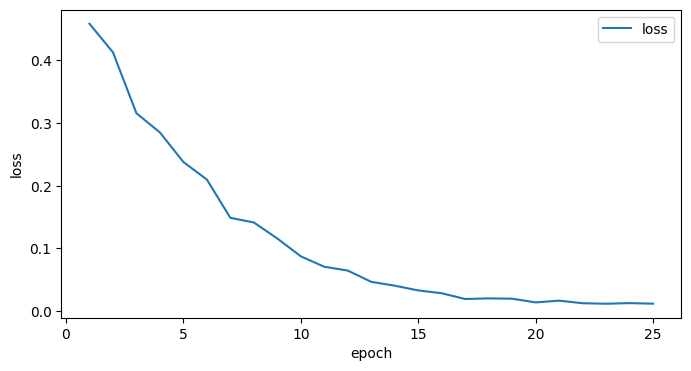

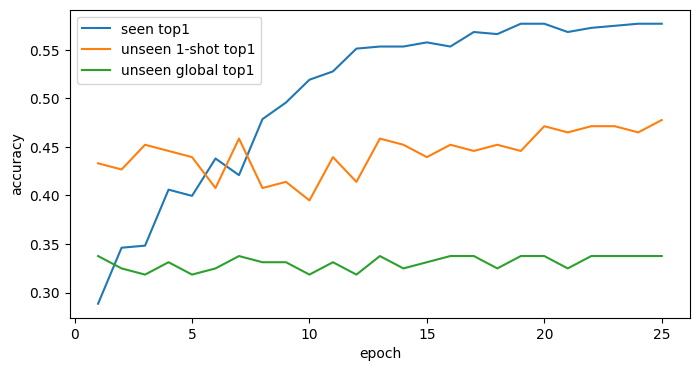

Loaded epoch: 25
Checkpoint metrics: {'seen_top1': 0.5769230769230769, 'seen_top5': 0.6239316239316239, 'seen_mAP': 0.5675288123493282, 'unseen1shot_top1': 0.47770700636942676, 'unseen1shot_top5': 0.5477707006369427, 'unseen1shot_mAP': 0.5197843228244374, 'unseen_global_top1': 0.3375796178343949, 'unseen_global_top5': 0.35668789808917195}


In [19]:
# ============================================================
# 21. Curves + load best checkpoint
# ============================================================
plt.figure(figsize=(8,4))
plt.plot(history_df.epoch, history_df.loss, label="loss")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.show()

plt.figure(figsize=(8,4))
if history_df.seen_top1.notna().any(): plt.plot(history_df.epoch, history_df.seen_top1, label="seen top1")
if history_df.unseen1shot_top1.notna().any(): plt.plot(history_df.epoch, history_df.unseen1shot_top1, label="unseen 1-shot top1")
if history_df.unseen_global_top1.notna().any(): plt.plot(history_df.epoch, history_df.unseen_global_top1, label="unseen global top1")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend(); plt.show()

ckpt = torch.load(best_path, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()
print("Loaded epoch:", ckpt["epoch"])
print("Checkpoint metrics:", ckpt["metrics"])

## 13. UNKNOWN / open-set calibration

In [20]:
# ============================================================
# 22. UNKNOWN threshold calibration
# ============================================================
def top1_and_margin(q, protos):
    if len(q)==0 or len(protos)==0:
        return np.array([]), np.array([])
    sim = q @ protos.T
    s = np.sort(sim, axis=1)[:, ::-1]
    top1 = s[:,0]
    margin = s[:,0] - s[:,1] if s.shape[1] > 1 else np.ones(len(s))
    return top1, margin

tr_emb = embed_indices(model, train_idx)
seen_protos, seen_proto_labels = build_prototypes(tr_emb, y[train_idx])
known_emb = embed_indices(model, seen_val_idx)
proxy_unknown_emb = embed_indices(model, unseen_query_idx)
known_cos, known_margin = top1_and_margin(known_emb, seen_protos)
unk_cos, unk_margin = top1_and_margin(proxy_unknown_emb, seen_protos)


def calibrate_gate(kc, km, uc, um):
    if len(kc)==0 or len(uc)==0:
        return DEFAULT_UNKNOWN_COS, DEFAULT_UNKNOWN_MARGIN, np.nan
    cos_grid = np.linspace(min(kc.min(), uc.min()), max(kc.max(), uc.max()), 50)
    mar_grid = np.linspace(0.0, max(km.max(), um.max(), 1e-3), 30)
    best = (-1, DEFAULT_UNKNOWN_COS, DEFAULT_UNKNOWN_MARGIN)
    for ct in cos_grid:
        for mt in mar_grid:
            known_pred = (kc >= ct) & (km >= mt)
            unk_pred_known = (uc >= ct) & (um >= mt)
            tpr = known_pred.mean()
            tnr = (~unk_pred_known).mean()
            bal = 0.5*(tpr+tnr)
            if bal > best[0]:
                best = (bal, float(ct), float(mt))
    return best[1], best[2], best[0]

UNKNOWN_COS, UNKNOWN_MARGIN, unknown_bal_acc = calibrate_gate(known_cos, known_margin, unk_cos, unk_margin)
print("Calibrated cosine threshold:", UNKNOWN_COS)
print("Calibrated margin threshold:", UNKNOWN_MARGIN)
print("Proxy balanced accuracy:", unknown_bal_acc)

Calibrated cosine threshold: 0.8428616523742676
Calibrated margin threshold: 0.02427084371447563
Proxy balanced accuracy: 0.7545593118841527


## 14. Build production prototypes

In [21]:
# ============================================================
# 23. Build production prototypes from ALL references
# ============================================================
all_idx = np.arange(len(X), dtype=np.int64)
all_emb = embed_indices(model, all_idx)
prototypes, prototype_labels = build_prototypes(all_emb, y)

np.savez_compressed(EXPORT_DIR / "prototypes.npz", prototypes=prototypes, prototype_labels=prototype_labels)

@torch.no_grad()
def stabilized_prototypes(model, n_aug=4):
    rng = np.random.default_rng(SEED+2026)
    per_label = defaultdict(list)
    model.eval()
    for i in tqdm(range(len(X)), desc="Stabilize prototypes"):
        views = [X[i]]
        for _ in range(n_aug):
            views.append(augment_sequence(X[i], rng, mild=True))
        arr = np.stack(views).astype(np.float32)
        embs=[]
        for s in range(0, len(arr), 32):
            embs.append(model(torch.from_numpy(arr[s:s+32]).to(DEVICE)).cpu().numpy())
        per_label[int(y[i])].append(np.concatenate(embs))
    labs = np.array(sorted(per_label), np.int64)
    ps=[]
    for lab in labs:
        p=np.concatenate(per_label[int(lab)]).mean(0)
        p/=np.linalg.norm(p)+1e-12
        ps.append(p)
    return np.asarray(ps,np.float32), labs

if STABILIZED_PROTO_AUGS > 0:
    stable_prototypes, stable_labels = stabilized_prototypes(model, STABILIZED_PROTO_AUGS)
    np.savez_compressed(EXPORT_DIR / "prototypes_stabilized.npz", prototypes=stable_prototypes, prototype_labels=stable_labels)
else:
    stable_prototypes, stable_labels = prototypes, prototype_labels

print("Production prototypes:", stable_prototypes.shape)

Stabilize prototypes:   0%|          | 0/4362 [00:00<?, ?it/s]

Production prototypes: (3315, 256)


## 15. Optional mask-aware DTW reranking

In [22]:
# ============================================================
# 24. Mask-aware DTW
# ============================================================
DTW_POINT_IDS = np.r_[np.arange(0, N_POSE), np.arange(N_POSE, N_POSE+2*N_HAND)]
DTW_WEIGHTS = np.ones(len(DTW_POINT_IDS), np.float32)
DTW_WEIGHTS[N_POSE:] = 2.0


def frame_masked_distance(a, b):
    # a,b [P,4]
    aa = a[DTW_POINT_IDS]; bb = b[DTW_POINT_IDS]
    valid = (aa[:,3] > 0.5) & (bb[:,3] > 0.5)
    if not valid.any():
        return 5.0
    d = np.linalg.norm(aa[valid,:3] - bb[valid,:3], axis=1)
    w = DTW_WEIGHTS[valid]
    return float(np.sum(d*w)/(np.sum(w)+1e-12))


def masked_dtw_distance(a, b):
    n,m = len(a),len(b)
    dp = np.full((n+1,m+1), np.inf, np.float32); dp[0,0]=0.0
    for i in range(1,n+1):
        for j in range(1,m+1):
            c = frame_masked_distance(a[i-1], b[j-1])
            dp[i,j] = c + min(dp[i-1,j], dp[i,j-1], dp[i-1,j-1])
    return float(dp[n,m]/(n+m))


def dtw_rerank(query_seq, cand_labels, cos_scores):
    ds=[]
    for lab in cand_labels:
        refs = X[y == int(lab)]
        ds.append(min(masked_dtw_distance(query_seq, r) for r in refs))
    ds=np.asarray(ds,np.float32)
    if len(ds)>1 and ds.max()>ds.min():
        dtw_sim = 1.0 - (ds-ds.min())/(ds.max()-ds.min()+1e-12)
    else:
        dtw_sim = np.ones_like(ds)
    cos01=(np.asarray(cos_scores)+1.0)/2.0
    final=COSINE_WEIGHT*cos01 + DTW_WEIGHT*dtw_sim
    o=np.argsort(-final)
    return np.asarray(cand_labels)[o], np.asarray(cos_scores)[o], ds[o], final[o]

In [23]:
# ============================================================
# 25. Final prediction API
# ============================================================
@torch.no_grad()
def predict_sequence(seq, topk=DTW_TOPK, use_dtw=True, use_stable=True):
    model.eval()
    q = model(torch.from_numpy(seq[None].astype(np.float32)).to(DEVICE)).cpu().numpy()
    P = stable_prototypes if use_stable else prototypes
    L = stable_labels if use_stable else prototype_labels
    pred, scores = topk_predict(q, P, L, topk)
    labs, cs = pred[0], scores[0]

    # UNKNOWN must be evaluated on embedding scores BEFORE DTW reorder.
    raw_top1 = float(cs[0])
    raw_margin = float(cs[0]-cs[1]) if len(cs)>1 else 1.0
    is_unknown = (raw_top1 < UNKNOWN_COS) or (raw_margin < UNKNOWN_MARGIN)

    if use_dtw:
        labs, cs, dd, fs = dtw_rerank(seq, labs, cs)
    else:
        dd=np.full(len(labs),np.nan); fs=cs

    rows=[]
    for lab,c,d,f in zip(labs,cs,dd,fs):
        rows.append({
            "label_id": int(lab), "gloss": id_to_label[int(lab)],
            "cosine": float(c), "dtw_distance": float(d) if np.isfinite(d) else np.nan,
            "final_score": float(f),
        })
    return pd.DataFrame(rows), bool(is_unknown), {"raw_top1_cosine":raw_top1,"raw_margin":raw_margin}

# sanity check: this is NOT an unbiased test because X[0] is from the dictionary itself.
demo_df, demo_unknown, demo_gate = predict_sequence(X[0])
display(demo_df)
print("unknown?", demo_unknown, demo_gate, "reference label:", id_to_label[int(y[0])])

,label_id,gloss,cosine,dtw_distance,final_score
0,3241,địa chỉ,0.932930,0.000000,0.973843
1,214,bánh cốm,0.628107,0.178094,0.713830
2,1480,kỉ luật,0.618305,0.190260,0.700366
3,1656,máy in,0.702596,0.252427,0.683975
4,949,doanh nghiệp,0.626263,0.264824,0.644382
5,3226,đếm,0.614725,0.274901,0.631896
6,3022,ít hơn,0.588985,0.277618,0.619704


unknown? False {'raw_top1_cosine': 0.9329304695129395, 'raw_margin': 0.23033487796783447} reference label: địa chỉ


## 16. Quick prediction from an existing saved keypoint sample

Đây chỉ là sanity-check, **không phải unbiased test**, vì sample nằm trong dictionary.

In [24]:
# ============================================================
# 26. Keypoint-only prediction demo
# ============================================================
QUERY_INDEX = 0

query_seq = X[QUERY_INDEX]
pred_df, is_unknown, gate_info = predict_sequence(query_seq)

display(pred_df)
print("UNKNOWN?", is_unknown)
print("Gate:", gate_info)
print("Reference gloss:", id_to_label[int(y[QUERY_INDEX])])
print("Reference path:", video_paths[QUERY_INDEX])

,label_id,gloss,cosine,dtw_distance,final_score
0,3241,địa chỉ,0.932930,0.000000,0.973843
1,214,bánh cốm,0.628107,0.178094,0.713830
2,1480,kỉ luật,0.618305,0.190260,0.700366
3,1656,máy in,0.702596,0.252427,0.683975
4,949,doanh nghiệp,0.626263,0.264824,0.644382
5,3226,đếm,0.614725,0.274901,0.631896
6,3022,ít hơn,0.588985,0.277618,0.619704


UNKNOWN? False
Gate: {'raw_top1_cosine': 0.9329304695129395, 'raw_margin': 0.23033487796783447}
Reference gloss: địa chỉ
Reference path: /kaggle/input/datasets/theait/vsl-vietnamese-sign-languages-full-videos-labels/Dataset/Videos/D0001N.mp4


## 17. Final evaluation snapshot

In [25]:
# ============================================================
# 27. Best-checkpoint metrics and detailed unseen report
# ============================================================
final_metrics = evaluate_all(model)
print(json.dumps(final_metrics, indent=2))

if len(unseen_query_idx):
    support_emb = embed_indices(model, unseen_support_idx)
    support_protos, support_labels = build_prototypes(support_emb, y[unseen_support_idx])
    query_emb = embed_indices(model, unseen_query_idx)
    pred5, score5 = topk_predict(query_emb, support_protos, support_labels, 5)
    report = pd.DataFrame({
        "video_path": video_paths[unseen_query_idx],
        "true_gloss": [id_to_label[int(v)] for v in y[unseen_query_idx]],
        "pred_gloss": [id_to_label[int(v)] for v in pred5[:,0]],
        "top1": pred5[:,0] == y[unseen_query_idx],
        "top5": [y[unseen_query_idx][i] in pred5[i] for i in range(len(unseen_query_idx))],
        "cosine": score5[:,0],
    })
    display(report.head(30))
    report.to_csv(EXPORT_DIR / "unseen_oneshot_predictions.csv", index=False)

{
  "seen_top1": 0.5769230769230769,
  "seen_top5": 0.6239316239316239,
  "seen_mAP": 0.5675288123493282,
  "unseen1shot_top1": 0.47770700636942676,
  "unseen1shot_top5": 0.5477707006369427,
  "unseen1shot_mAP": 0.5197843228244374,
  "unseen_global_top1": 0.3375796178343949,
  "unseen_global_top5": 0.35668789808917195
}


,video_path,true_gloss,pred_gloss,top1,top5,cosine
0,/kaggle/input/datasets/theait/vsl-vietnamese-s...,Trung Quốc (nước Trung Quốc),em rể,False,False,0.473293
1,/kaggle/input/datasets/theait/vsl-vietnamese-s...,Trung Quốc (nước Trung Quốc),Trung Quốc (nước Trung Quốc),True,True,0.999527
2,/kaggle/input/datasets/theait/vsl-vietnamese-s...,anh họ,anh họ,True,True,0.958426
3,/kaggle/input/datasets/theait/vsl-vietnamese-s...,anh rể,anh rể,True,True,0.514856
4,/kaggle/input/datasets/theait/vsl-vietnamese-s...,anh rể,anh rể,True,True,0.502038
5,/kaggle/input/datasets/theait/vsl-vietnamese-s...,buổi tối,buổi tối,True,True,0.999138
6,/kaggle/input/datasets/theait/vsl-vietnamese-s...,buổi tối,t,False,False,0.401259
7,/kaggle/input/datasets/theait/vsl-vietnamese-s...,buổi đêm,buổi đêm,True,True,0.612716
8,/kaggle/input/datasets/theait/vsl-vietnamese-s...,buổi đêm,buổi đêm,True,True,0.650565
9,/kaggle/input/datasets/theait/vsl-vietnamese-s...,bánh mì,anh họ,False,False,0.551314


In [26]:
# ============================================================
# 28. Save deployment config / references
# ============================================================
config = {
    "seed": SEED,
    "seq_len": SEQ_LEN,
    "n_points": N_POINTS,
    "use_face": USE_FACE,
    "face_idx": [],  # compact-face indices are already baked into saved keypoints,
    "embedding_dim": EMBED_DIM,
    "representation": "MediaPipe Holistic normalized structured keypoints; local hand coords + motion + optional hand angles",
    "unknown_cosine_threshold": float(UNKNOWN_COS),
    "unknown_margin_threshold": float(UNKNOWN_MARGIN),
    "dtw_topk": DTW_TOPK,
    "cosine_weight": COSINE_WEIGHT,
    "dtw_weight": DTW_WEIGHT,
    "evaluation": {
        "unseen_glosses": len(unseen_labels),
        "unseen_support_per_gloss": UNSEEN_SUPPORT_PER_CLASS,
        "note": "single-video classes have no independent same-class test inside this dataset",
    },
}
(EXPORT_DIR / "inference_config.json").write_text(json.dumps(config, ensure_ascii=False, indent=2), encoding="utf-8")

np.savez_compressed(
    EXPORT_DIR / "reference_sequences.npz",
    X=X.astype(np.float16), y=y.astype(np.int64), video_paths=video_paths,
)

print(json.dumps(config, ensure_ascii=False, indent=2))

{
  "seed": 42,
  "seq_len": 48,
  "n_points": 115,
  "use_face": true,
  "face_idx": [],
  "embedding_dim": 256,
  "representation": "MediaPipe Holistic normalized structured keypoints; local hand coords + motion + optional hand angles",
  "unknown_cosine_threshold": 0.8428616523742676,
  "unknown_margin_threshold": 0.02427084371447563,
  "dtw_topk": 7,
  "cosine_weight": 0.78,
  "dtw_weight": 0.22,
  "evaluation": {
    "unseen_glosses": 82,
    "unseen_support_per_gloss": 1,
    "note": "single-video classes have no independent same-class test inside this dataset"
  }
}


In [27]:
# ============================================================
# 29. Optional ONNX export
# ============================================================
if EXPORT_ONNX:
    onnx_path = EXPORT_DIR / "vsl_metric_encoder.onnx"
    dummy = torch.randn(1, SEQ_LEN, N_POINTS, POINT_DIM, device=DEVICE)
    model.eval()
    try:
        torch.onnx.export(
            model, dummy, onnx_path,
            input_names=["keypoints"], output_names=["embedding"],
            dynamic_axes={"keypoints":{0:"batch"}, "embedding":{0:"batch"}},
            opset_version=17, do_constant_folding=True,
        )
        print("ONNX saved:", onnx_path)
    except Exception as e:
        print("ONNX export failed:", repr(e))
        print("PyTorch checkpoint is still available.")
else:
    print("ONNX export disabled. Set EXPORT_ONNX=True if needed.")

ONNX export disabled. Set EXPORT_ONNX=True if needed.


In [28]:
# ============================================================
# 30. Artifact listing
# ============================================================
print("WORK_DIR:", WORK_DIR)
for p in sorted(EXPORT_DIR.glob("*")):
    print(f"{p.name:38s} {p.stat().st_size/(1024*1024):8.2f} MB")
print("\nOn Kaggle, use Save Version to persist outputs.")

WORK_DIR: /kaggle/working/vsl_train_from_keypoints
best_vsl_metric_encoder.pt                 7.71 MB
inference_config.json                      0.00 MB
prototypes.npz                             3.00 MB
prototypes_stabilized.npz                  3.00 MB
reference_sequences.npz                  119.41 MB
training_history.csv                       0.01 MB
unseen_oneshot_predictions.csv             0.02 MB

On Kaggle, use Save Version to persist outputs.


# Expected runtime after skipping MediaPipe

Trên P100/T4, phần này thường nhẹ hơn rất nhiều so với extraction:

- Load/audit keypoints: vài phút.
- SSL 3 epochs: thường vài–vài chục phút.
- Metric training 25 epochs: thường khoảng vài chục phút đến ~1–2 giờ tùy GPU/runtime.
- Prototype/evaluation: thêm vài phút đến vài chục phút.

Nếu chỉ muốn smoke test pipeline trước, đổi:
```python
SELF_SUP_EPOCHS = 1
BATCHES_PER_EPOCH = 40
METRIC_EPOCHS = 3
STABILIZED_PROTO_AUGS = 0
```

Sau khi pipeline chạy ổn, trả lại config mặc định để train final.